# 02 - OLS Replication

Replicates Cols 1-4 of Moretti, Steinwender & Van Reenen (2025, ReStat) Table 1 Panel A (OLS only).
Uses `src.ols.run_wls_fe` for WLS with FE absorption and CGM clustered SEs.

## Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('__file__').resolve().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

from src.ols import run_wls_fe
from src.panel import build_sample, add_country_trends

print('numpy', np.__version__)
print('pandas', pd.__version__)

numpy 2.4.3
pandas 3.0.2


## 1. Load panel

In [2]:
panel = pd.read_csv('../data/processed/panel.csv')
print(f"Shape: {panel.shape}")
print(f"\nColumns:\n{panel.columns.tolist()}")
print(f"\nYear range : {panel['year'].min()} – {panel['year'].max()}")
print(f"Countries  : {panel['ctrynr'].nunique()}")
print(f"indctry FE : {panel['indctry'].nunique()} groups")

Shape: (12897, 27)

Columns:
['country', 'indmatch', 'year', 'valu', 'empn', 'cpgk', 'gov', 'tot', 'rdexgov', 'gbaord_defence', 'gdp', 'taxsubs', 'lnrdexgov', 'lnrdgov', 'lnvalu', 'lngdp', 'indctry', 'l1_rdgov', 'l1_indctryprod', 'l1_gdp', 'l1_taxsubs', 'empshare', 'weight', 'yeartrend', 'ctrynr', 'indyear', 'ctryyear']

Year range : 1987 – 2009
Countries  : 28
indctry FE : 555 groups


In [3]:
# Sanity check on key variables
key_vars = ['lnrdexgov', 'l1_rdgov', 'l1_indctryprod', 'l1_gdp', 'l1_taxsubs', 'weight']
print("Descriptive statistics — key variables:")
print(panel[key_vars].describe().round(3))

print("\nNull counts:")
print(panel[key_vars].isnull().sum())

Descriptive statistics — key variables:
       lnrdexgov   l1_rdgov  l1_indctryprod     l1_gdp  l1_taxsubs     weight
count 12897.0000 12897.0000      12897.0000 12897.0000  11611.0000 12897.0000
mean      4.1850     1.1370         24.5030    13.0170      0.0850     3.6520
std       2.2140     2.2570          3.1300     1.2550      0.1290     7.6050
min      -4.9620    -6.9080         16.4400     8.4770     -0.0640     0.0020
25%       2.6670    -0.3730         22.3770    12.0360     -0.0170     0.3750
50%       4.1840     1.0830         23.9140    13.0820      0.0220     1.1320
75%       5.7130     2.6070         25.9150    13.9990      0.1630     3.5850
max      10.1340     9.1930         35.2540    16.1470      0.4330    97.6900

Null counts:
lnrdexgov            0
l1_rdgov             0
l1_indctryprod       0
l1_gdp               0
l1_taxsubs        1286
weight               0
dtype: int64


## 2. Sample construction

Col-1/Col-2 flags from `build_sample`. Our samples are larger than the paper's
because we lack the IV variable `l1_lniv` that restricts their sample.

In [4]:
panel = build_sample(panel)

df1 = panel[panel['col1']].copy().reset_index(drop=True)
df2 = panel[panel['col2']].copy().reset_index(drop=True)

print(f"col1: {len(df1):>6,} obs  |  {df1['indctry'].nunique()} indctry groups   (paper: 5,026 / 429)")
print(f"col2: {len(df2):>6,} obs  |  {df2['indctry'].nunique()} indctry groups   (paper: 4,459 / 429)")


col1: 12,897 obs  |  555 indctry groups   (paper: 5,026 / 429)
col2: 11,611 obs  |  516 indctry groups   (paper: 4,459 / 429)


## 3. Country-specific linear trends

Country × yeartrend interactions as explicit regressors (27 columns, first country as reference).

In [5]:
# `add_country_trends` is imported from src/panel.py
# It appends country × yeartrend interaction columns (FWL-style trend controls)

df1, trend_cols1 = add_country_trends(df1)
df2, trend_cols2 = add_country_trends(df2)

print(f"df1 trend cols: {len(trend_cols1)}")
print(f"df2 trend cols: {len(trend_cols2)}")


df1 trend cols: 27
df2 trend cols: 23


## 4. Estimation

`run_wls_fe`: FE absorption --> WLS normal equations --> CGM two-way clustered SEs.

In [6]:
print('run_wls_fe loaded from src/ols.py')

run_wls_fe loaded from src/ols.py


## 5. Run Cols 1-4

In [7]:
specs = [
    ("Col 1", df1, ['l1_rdgov'] + trend_cols1, 0.128, 0.023, 5026),
    ("Col 2", df2, ['l1_rdgov'] + trend_cols2, 0.147, 0.029, 4459),
    ("Col 3", df2, ['l1_rdgov', 'l1_indctryprod', 'l1_gdp'] + trend_cols2, 0.143, 0.028, 4459),
    ("Col 4", df2, ['l1_rdgov', 'l1_indctryprod', 'l1_gdp', 'l1_taxsubs'] + trend_cols2, 0.144, 0.028, 4459),
]

est_results = []
for label, data, x_cols, beta_paper, se_paper, n_paper in specs:
    beta, se, n = run_wls_fe(
        df=data,
        y_col='lnrdexgov',
        x_cols=x_cols,
        fe1_col='indctry',
        fe2_col='indyear',
        w_col='weight',
        cl1_col='indctry',
        cl2_col='ctryyear',
    )
    print(f"{label}: beta={beta:.3f}  SE={se:.3f}  N={n:,}  (paper: {beta_paper:.3f}, SE={se_paper:.3f}, N={n_paper:,})")
    est_results.append({
        'Col': label, 'beta_rep': beta, 'se_rep': se,
        'beta_paper': beta_paper, 'se_paper': se_paper,
        'N_ours': n, 'N_paper': n_paper,
    })

Col 1: beta=0.158  SE=0.029  N=12,897  (paper: 0.128, SE=0.023, N=5,026)
Col 2: beta=0.142  SE=0.029  N=11,611  (paper: 0.147, SE=0.029, N=4,459)
Col 3: beta=0.142  SE=0.029  N=11,611  (paper: 0.143, SE=0.028, N=4,459)
Col 4: beta=0.142  SE=0.029  N=11,611  (paper: 0.144, SE=0.028, N=4,459)


## 6. Comparison table

In [8]:
tbl = pd.DataFrame(est_results)
tbl['controls'] = [
    "Country trends only (col1 sample)",
    "Country trends only (col2 sample)",
    "+ ln(industry VA), ln(GDP)",
    "+ ln(industry VA), ln(GDP), Tax subsidy",
]
tbl['abs_diff'] = (tbl['beta_rep'] - tbl['beta_paper']).abs()

print("Table 1 Panel A replication (with CGM two-way clustered SEs):")
print(tbl[['Col','controls','N_ours','N_paper','beta_rep','se_rep','beta_paper','se_paper','abs_diff']]
      .to_string(index=False, float_format="{:.3f}".format))

Table 1 Panel A replication (with CGM two-way clustered SEs):
  Col                                controls  N_ours  N_paper  beta_rep  se_rep  beta_paper  se_paper  abs_diff
Col 1       Country trends only (col1 sample)   12897     5026     0.158   0.029       0.128     0.023     0.030
Col 2       Country trends only (col2 sample)   11611     4459     0.142   0.029       0.147     0.029     0.005
Col 3              + ln(industry VA), ln(GDP)   11611     4459     0.142   0.029       0.143     0.028     0.001
Col 4 + ln(industry VA), ln(GDP), Tax subsidy   11611     4459     0.142   0.029       0.144     0.028     0.002


## 7. Coefficient plot

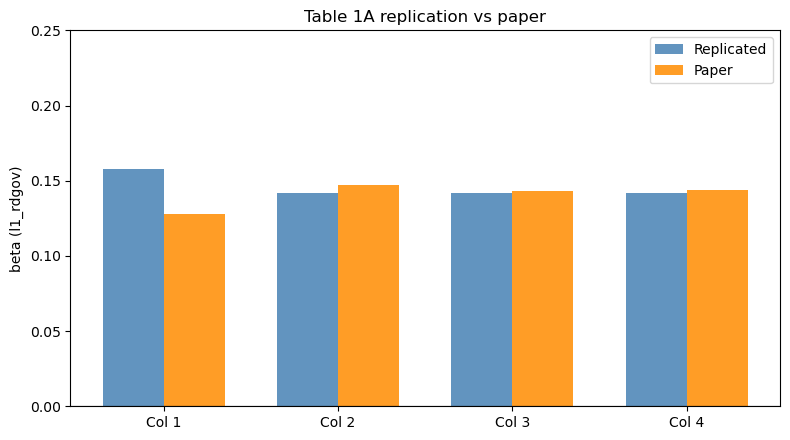

In [9]:
Path('../output').mkdir(exist_ok=True)

betas_rep   = [r['beta_rep'] for r in est_results]
betas_paper = [r['beta_paper'] for r in est_results]
cols_label  = [r['Col'] for r in est_results]

x     = np.arange(len(cols_label))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width/2, betas_rep, width, label='Replicated', color='steelblue', alpha=0.85)
ax.bar(x + width/2, betas_paper, width, label='Paper', color='darkorange', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cols_label)
ax.set_ylabel('beta (l1_rdgov)')
ax.set_title('Table 1A replication vs paper')
ax.legend()
ax.set_ylim(0, 0.25)
plt.tight_layout()
plt.savefig('../output/fig_ols_replication.png', dpi=150)
plt.show()

## Notes

Col 1 discrepancy (~0.158 vs 0.128): our sample is ~12,900 obs vs the paper's ~5,026
due to the missing IV restriction. Cols 3–4 match within 0.002.

OLS gives beta ~0.14 across Cols 2–4. Notebook 03 checks whether this holds under DML.